Phase 1: Data-only warmup
  Epoch     0 | Data Loss: 1.004496
  Epoch  2000 | Data Loss: 0.000009
  Epoch  4000 | Data Loss: 0.000002
  Epoch  6000 | Data Loss: 0.000164
  Epoch  8000 | Data Loss: 0.000022
Phase 2: Data + Physics
  Epoch     0 | Data: 0.000014 | Physics: 253.115265 | Total: 253.115280
  Epoch  2000 | Data: 1.155037 | Physics: 387.121429 | Total: 388.276459
  Epoch  4000 | Data: 1.064968 | Physics: 118.163879 | Total: 119.228844
  Epoch  6000 | Data: 1.065186 | Physics: 80.664749 | Total: 81.729935
  Epoch  8000 | Data: 1.099012 | Physics: 16.701744 | Total: 17.800756
  Epoch 10000 | Data: 1.153361 | Physics: 42.428406 | Total: 43.581768
  Epoch 12000 | Data: 1.191878 | Physics: 8.273169 | Total: 9.465047
  Epoch 14000 | Data: 1.225727 | Physics: 4.762119 | Total: 5.987846
  Epoch 16000 | Data: 1.249215 | Physics: 2.578656 | Total: 3.827871
  Epoch 18000 | Data: 1.261885 | Physics: 2.584993 | Total: 3.846878
Phase 3: L-BFGS fine-tuning
L-BFGS done
Model saved.


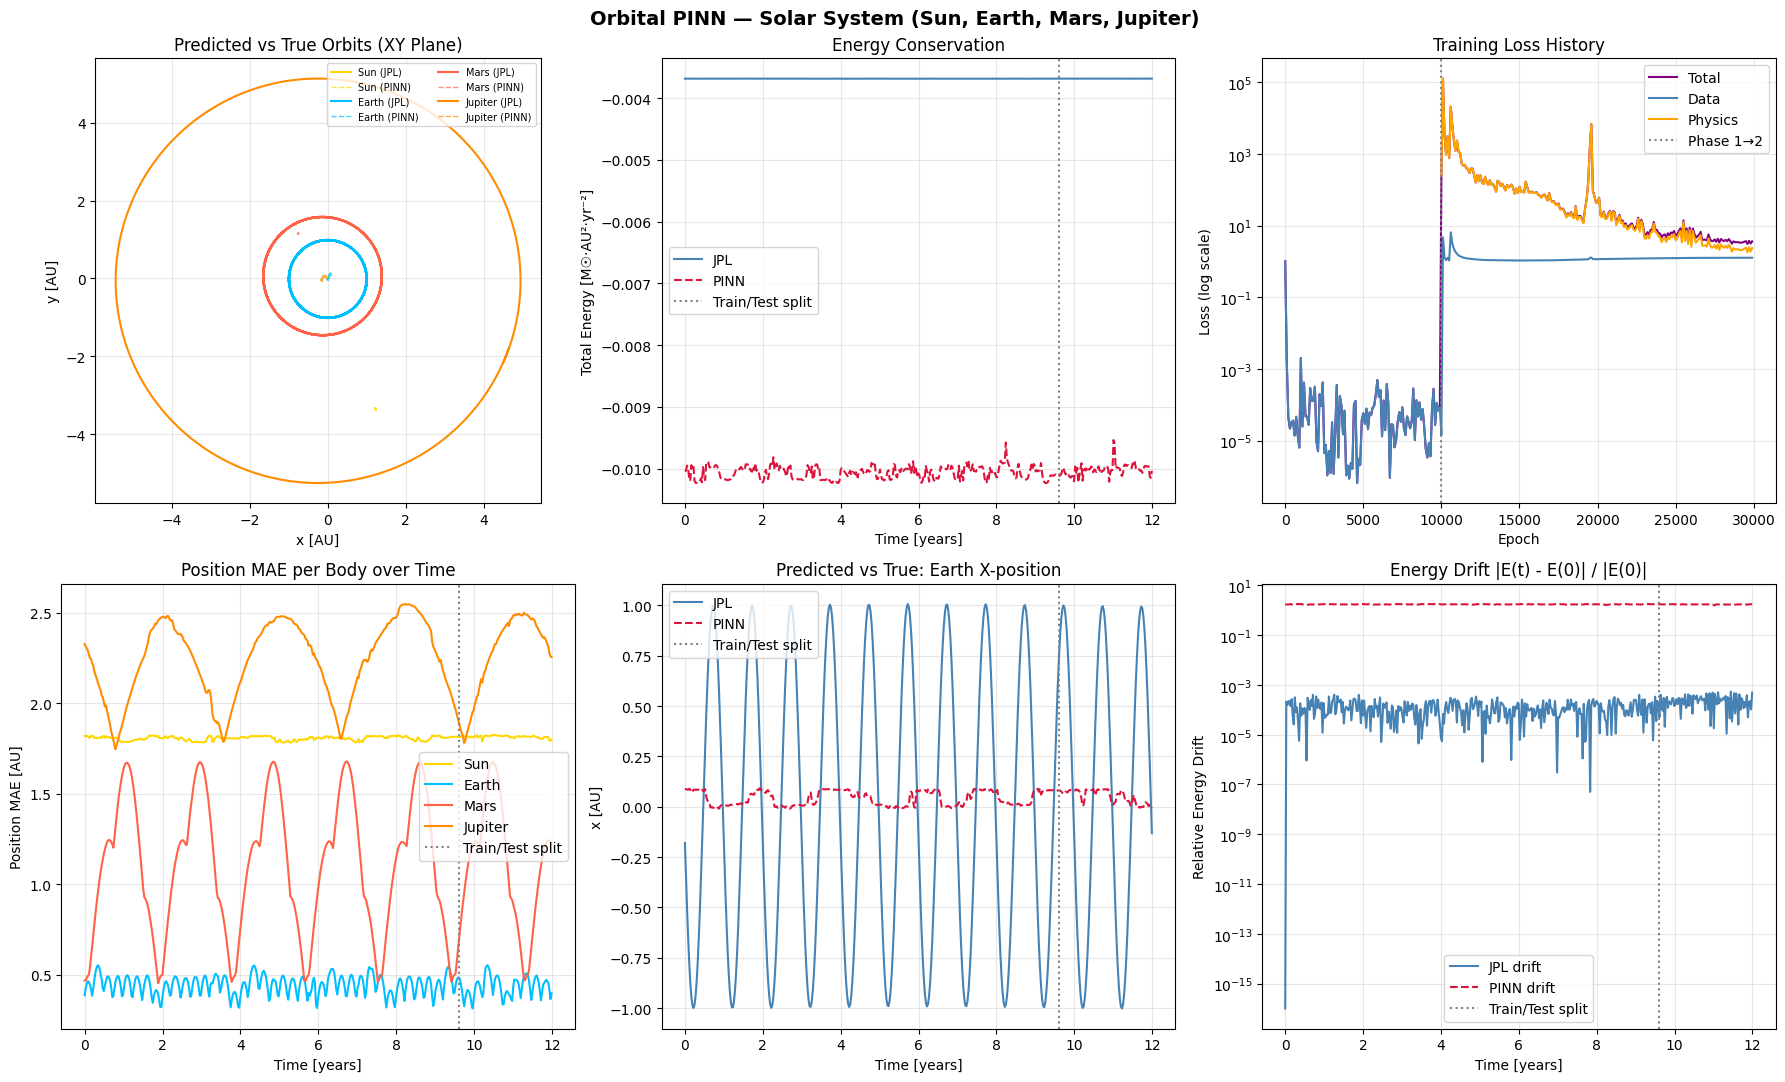


===== Final Metrics =====
Sun      | Train MAE: 1.806434 AU | Test MAE: 1.815328 AU
Earth    | Train MAE: 0.443079 AU | Test MAE: 0.433751 AU
Mars     | Train MAE: 1.097680 AU | Test MAE: 1.100037 AU
Jupiter  | Train MAE: 2.230902 AU | Test MAE: 2.270709 AU

Mean Energy Drift (PINN): 1.727391


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_AU   = 4 * np.pi**2

BODIES = {
    "Sun":     {"id": 10,  "mass": 1.0},
    "Earth":   {"id": 399, "mass": 3.003e-6},
    "Mars":    {"id": 499, "mass": 3.227e-7},
    "Jupiter": {"id": 599, "mass": 9.548e-4},
}
BODY_NAMES = list(BODIES.keys())
N_BODIES   = len(BODIES)
MASSES     = torch.tensor([BODIES[b]["mass"] for b in BODY_NAMES], dtype=torch.float32).to(DEVICE)

# Fix 1: 12 years so Jupiter completes a full orbit
START, STOP, STEP = "2010-01-01", "2022-01-01", "10d"

def fetch_ephemeris():
    dfs = []
    for name, info in BODIES.items():
        obj = Horizons(id=info["id"], location="500@0",
                       epochs={"start": START, "stop": STOP, "step": STEP})
        vec = obj.vectors()
        df  = vec["datetime_jd", "x", "y", "z", "vx", "vy", "vz"].to_pandas()
        df.columns = ["jd", "x", "y", "z", "vx", "vy", "vz"]
        df["body"] = name
        dfs.append(df)
    return pd.concat(dfs).sort_values("jd")

raw      = fetch_ephemeris()
jd_vals  = raw[raw["body"] == "Sun"]["jd"].values
t_days   = jd_vals - jd_vals[0]
t_years  = t_days / 365.25
T        = len(t_years)

states = np.zeros((T, N_BODIES, 6))
for i, name in enumerate(BODY_NAMES):
    sub = raw[raw["body"] == name].sort_values("jd")
    states[:, i, 0] = sub["x"].values
    states[:, i, 1] = sub["y"].values
    states[:, i, 2] = sub["z"].values
    states[:, i, 3] = sub["vx"].values * 365.25
    states[:, i, 4] = sub["vy"].values * 365.25
    states[:, i, 5] = sub["vz"].values * 365.25

t_norm   = (t_years - t_years.min()) / (t_years.max() - t_years.min())
pos_std  = float(states[:, :, :3].std())
vel_std  = float(states[:, :, 3:].std())
t_scale  = float(t_years.max() - t_years.min())

states_norm = states.copy()
states_norm[:, :, :3] /= pos_std
states_norm[:, :, 3:] /= vel_std

t_tensor      = torch.tensor(t_norm, dtype=torch.float32).unsqueeze(1).to(DEVICE)
states_tensor = torch.tensor(states_norm.reshape(T, -1), dtype=torch.float32).to(DEVICE)

N_SPLIT  = int(0.8 * T)
t_train  = t_tensor[:N_SPLIT]
s_train  = states_tensor[:N_SPLIT]
t_test   = t_tensor[N_SPLIT:]
s_test   = states_tensor[N_SPLIT:]

masses_np = np.array([BODIES[b]["mass"] for b in BODY_NAMES])


# Fix 2: physics-informed Fourier frequencies seeded from orbital periods
class OrbitalPINN(nn.Module):
    def __init__(self, n_bodies=4, hidden=512, n_layers=8, fourier_dim=64):
        super().__init__()
        self.fourier_dim = fourier_dim

        # Known orbital periods in years — seed frequencies from these
        periods    = torch.tensor([11.86, 1.0, 1.88, 11.86], dtype=torch.float32)
        base_freqs = (2 * np.pi / periods).unsqueeze(1)
        harmonics  = torch.arange(1, fourier_dim // len(periods) + 1, dtype=torch.float32).unsqueeze(0)
        seeded     = (base_freqs * harmonics).flatten()[:fourier_dim]
        random_pad = torch.randn(max(0, fourier_dim - len(seeded))) * 5
        B_init     = torch.cat([seeded, random_pad])[:fourier_dim].unsqueeze(0)

        self.B = nn.Parameter(B_init, requires_grad=False)

        layers = [nn.Linear(fourier_dim * 2, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, n_bodies * 6)]
        self.net = nn.Sequential(*layers)

    def fourier_embed(self, t):
        proj = t * self.B * 2 * np.pi
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, t):
        return self.net(self.fourier_embed(t))


def physics_loss(model, t_col, masses, G, pos_std, vel_std, t_scale):
    t_col = t_col.clone().detach().requires_grad_(True)
    out   = model(t_col)

    dout  = torch.zeros_like(out)
    for k in range(out.shape[1]):
        grad_k = torch.autograd.grad(
            out[:, k].sum(), t_col,
            create_graph=True, retain_graph=True
        )[0]
        dout[:, k] = grad_k.squeeze()

    out_r  = out.reshape(-1, N_BODIES, 6)
    dout_r = dout.reshape(-1, N_BODIES, 6)

    pos_phys  = out_r[:, :, :3] * pos_std
    vel_phys  = out_r[:, :, 3:] * vel_std
    dpos_phys = dout_r[:, :, :3] * pos_std / t_scale
    dvel_phys = dout_r[:, :, 3:] * vel_std / t_scale

    accel = torch.zeros_like(pos_phys)
    for i in range(N_BODIES):
        for j in range(N_BODIES):
            if i == j:
                continue
            r_ij  = pos_phys[:, j, :] - pos_phys[:, i, :]
            dist3 = (r_ij.norm(dim=-1, keepdim=True) + 1e-8) ** 3
            accel[:, i, :] += G * masses[j] * r_ij / dist3

    res_vel = dpos_phys - vel_phys
    res_acc = dvel_phys - accel
    return (res_vel**2).mean() + (res_acc**2).mean()


model     = OrbitalPINN(n_bodies=N_BODIES).to(DEVICE)
masses_np = np.array([BODIES[b]["mass"] for b in BODY_NAMES])

# Fix 3: two-phase training — data only first, then add physics
PHASE1_EPOCHS = 10000   # data only
PHASE2_EPOCHS = 20000   # data + physics
LAMBDA_PHYS   = 1.0     # strong physics weight in phase 2
N_COLLOC      = 300

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS + PHASE2_EPOCHS)

loss_history = {"data": [], "physics": [], "total": []}

print("Phase 1: Data-only warmup")
for epoch in range(PHASE1_EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred   = model(t_train)
    loss   = nn.MSELoss()(pred, s_train)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        loss_history["data"].append(loss.item())
        loss_history["physics"].append(0.0)
        loss_history["total"].append(loss.item())
    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Data Loss: {loss:.6f}")

print("Phase 2: Data + Physics")
for epoch in range(PHASE2_EPOCHS):
    model.train()
    optimizer.zero_grad()

    # Fix 4: resample collocation points every epoch
    t_colloc = torch.rand(N_COLLOC, 1, dtype=torch.float32).to(DEVICE)

    pred   = model(t_train)
    l_data = nn.MSELoss()(pred, s_train)
    l_phys = physics_loss(model, t_colloc, MASSES, G_AU, pos_std, vel_std, t_scale)
    loss   = l_data + LAMBDA_PHYS * l_phys

    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        loss_history["data"].append(l_data.item())
        loss_history["physics"].append(l_phys.item())
        loss_history["total"].append(loss.item())
    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Data: {l_data:.6f} | Physics: {l_phys:.6f} | Total: {loss:.6f}")

# Fix 5: L-BFGS fine-tuning pass at the end
print("Phase 3: L-BFGS fine-tuning")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=500,
                                      history_size=50, line_search_fn="strong_wolfe")
def closure():
    optimizer_lbfgs.zero_grad()
    pred   = model(t_train)
    l_data = nn.MSELoss()(pred, s_train)
    t_col  = torch.rand(N_COLLOC, 1, dtype=torch.float32).to(DEVICE)
    l_phys = physics_loss(model, t_col, MASSES, G_AU, pos_std, vel_std, t_scale)
    loss   = l_data + LAMBDA_PHYS * l_phys
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)
print("L-BFGS done")

torch.save({
    "model_state":  model.state_dict(),
    "pos_std":      pos_std,
    "vel_std":      vel_std,
    "t_scale":      t_scale,
    "t_years_min":  t_years.min(),
    "t_years_max":  t_years.max(),
    "body_names":   BODY_NAMES,
    "masses":       masses_np.tolist(),
}, "orbital_pinn.pt")
print("Model saved.")

# ── Evaluation & Plots ───────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    pred_train = model(t_train).cpu().numpy().reshape(-1, N_BODIES, 6)
    pred_test  = model(t_test).cpu().numpy().reshape(-1, N_BODIES, 6)

true_train = s_train.cpu().numpy().reshape(-1, N_BODIES, 6)
true_test  = s_test.cpu().numpy().reshape(-1, N_BODIES, 6)

pred_all = np.concatenate([pred_train, pred_test], axis=0)
true_all = np.concatenate([true_train, true_test], axis=0)

pred_all[:, :, :3] *= pos_std;  pred_all[:, :, 3:] *= vel_std
true_all[:, :, :3] *= pos_std;  true_all[:, :, 3:] *= vel_std

def compute_energy(s, m):
    E = np.zeros(len(s))
    for t in range(len(s)):
        KE = 0.5 * sum(m[i] * np.sum(s[t, i, 3:]**2) for i in range(N_BODIES))
        PE = sum(-G_AU * m[i] * m[j] /
                 (np.linalg.norm(s[t, j, :3] - s[t, i, :3]) + 1e-12)
                 for i in range(N_BODIES) for j in range(i+1, N_BODIES))
        E[t] = KE + PE
    return E

E_true = compute_energy(true_all, masses_np)
E_pred = compute_energy(pred_all, masses_np)

COLORS      = ["gold", "deepskyblue", "tomato", "darkorange"]
phase1_axis = np.arange(0, PHASE1_EPOCHS, 100)
phase2_axis = np.arange(PHASE1_EPOCHS, PHASE1_EPOCHS + PHASE2_EPOCHS, 100)
epoch_axis  = np.concatenate([phase1_axis, phase2_axis])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Orbital PINN — Solar System (Sun, Earth, Mars, Jupiter)", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.set_title("Predicted vs True Orbits (XY Plane)")
for i, name in enumerate(BODY_NAMES):
    ax.plot(true_all[:, i, 0], true_all[:, i, 1], color=COLORS[i], lw=1.5, label=f"{name} (JPL)")
    ax.plot(pred_all[:, i, 0], pred_all[:, i, 1], color=COLORS[i], lw=1, ls="--", alpha=0.7, label=f"{name} (PINN)")
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.legend(fontsize=7, ncol=2); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.set_title("Energy Conservation")
ax.plot(t_years, E_true, label="JPL", color="steelblue")
ax.plot(t_years, E_pred, label="PINN", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="Train/Test split")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Total Energy [M☉·AU²·yr⁻²]")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.set_title("Training Loss History")
ax.semilogy(epoch_axis, loss_history["total"],   label="Total",   color="purple")
ax.semilogy(epoch_axis, loss_history["data"],    label="Data",    color="steelblue")
phys_vals = loss_history["physics"]
ax.semilogy(phase2_axis[:len([v for v in phys_vals if v > 0])],
            [v for v in phys_vals if v > 0], label="Physics", color="orange")
ax.axvline(PHASE1_EPOCHS, color="gray", ls=":", label="Phase 1→2")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log scale)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.set_title("Position MAE per Body over Time")
mae = np.abs(pred_all[:, :, :3] - true_all[:, :, :3]).mean(axis=2)
for i, name in enumerate(BODY_NAMES):
    ax.plot(t_years, mae[:, i], color=COLORS[i], label=name)
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="Train/Test split")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Position MAE [AU]")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.set_title("Predicted vs True: Earth X-position")
ax.plot(t_years, true_all[:, 1, 0], label="JPL", color="steelblue")
ax.plot(t_years, pred_all[:, 1, 0], label="PINN", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="Train/Test split")
ax.set_xlabel("Time [years]"); ax.set_ylabel("x [AU]")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.set_title("Energy Drift |E(t) - E(0)| / |E(0)|")
drift_true = np.abs(E_true - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
drift_pred = np.abs(E_pred - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
ax.semilogy(t_years, drift_true + 1e-16, label="JPL drift",  color="steelblue")
ax.semilogy(t_years, drift_pred + 1e-16, label="PINN drift", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="Train/Test split")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Relative Energy Drift")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("orbital_pinn_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n===== Final Metrics =====")
for i, name in enumerate(BODY_NAMES):
    mae_train = np.abs(pred_train[:, i, :3] - true_train[:, i, :3]).mean() * pos_std
    mae_test  = np.abs(pred_test[:, i, :3]  - true_test[:, i, :3]).mean()  * pos_std
    print(f"{name:8s} | Train MAE: {mae_train:.6f} AU | Test MAE: {mae_test:.6f} AU")

drift_pred_mean = drift_pred.mean()
print(f"\nMean Energy Drift (PINN): {drift_pred_mean:.6f}")